# Proyek Analisis Data: [Bike-sharing-dataset]
- **Nama:** [Ilham Sanusi]
- **Email:** [CDCC282D6Y2105@student.devacademy.id]
- **ID Dicoding:** [CDCC282D6Y2105]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Pertanyaan 1** : ***"Bagaimana pengaruh kondisi cuaca (weathersit) terhadap rata-rata jumlah penyewaan sepeda (cnt) pada sistem bike sharing di Washington D.C. selama periode 2011–2012?"***

Keterangan:

- **Specific**: Fokus pada "kondisi cuaca (weathersit)" dan "jumlah penyewaan sepeda (cnt)" pada sistem bike sharing.
- **Measurable**: Menggunakan metrik rata-rata jumlah penyewaan sepeda (cnt).
- **Action-Oriented**: Hasil analisis dapat digunakan untuk menentukan strategi operasional seperti penyesuaian jumlah sepeda atau promosi.
- **Relevant**: Cuaca merupakan faktor utama yang memengaruhi penggunaan layanan bike sharing.
- **Time-bound**: Dibatasi pada periode spesifik "tahun 2011–2012".

**Pertanyaan 2** : ***"Bagaimana pengaruh kondisi cuaca (weathersit) terhadap rata-rata jumlah penyewaan sepeda (cnt) pada sistem bike sharing di Washington D.C. selama periode 2011–2012?"***

Keterangan:

- **Specific**: Fokus pada "kondisi cuaca (weathersit)" dan "jumlah penyewaan sepeda (cnt)" pada sistem bike sharing.
- **Measurable**: Menggunakan metrik rata-rata jumlah penyewaan sepeda (cnt).
- **Action-Oriented**: Hasil analisis dapat digunakan untuk menentukan strategi operasional seperti penyesuaian jumlah sepeda atau promosi.
- **Relevant**: Cuaca merupakan faktor utama yang memengaruhi penggunaan layanan bike sharing.
- **Time-bound**: Dibatasi pada periode spesifik "tahun 2011–2012".

## Import Semua Packages/Library yang Digunakan

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Data Wrangling

### Gathering Data

#### Load df ...

In [3]:
day_df = pd.read_csv('data_1.csv')
hour_df = pd.read_csv('data_2.csv')

day_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)

- Dataset berhasil dimuat ke dalam DataFrame tanpa kendala.
- Dataset `day_df` berisi data penyewaan sepeda yang telah diagregasi per hari.
- Dataset `hour_df` berisi data penyewaan sepeda yang lebih detail per jam.
- Dataset memiliki berbagai fitur seperti kondisi cuaca, musim, suhu, dan jumlah penyewaan sepeda (`cnt`) yang dapat digunakan untuk analisis lebih lanjut.

### Assessing Data

#### Identifying ... problem

1. Kolom `dteday` masih bertipe object sehingga perlu dikonversi menjadi datetime.
2. Terdapat nilai maksimum pada kolom `cnt` yang cukup tinggi dibandingkan rata-rata, sehingga berpotensi sebagai outlier.

In [4]:
day_df.info()
day_df.isna().sum()
day_df.duplicated().sum()
day_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Steps to Take:**
- Mengubah tipe data kolom `dteday` menjadi datetime.
- Melakukan analisis terhadap distribusi data pada kolom `cnt` untuk memahami pengaruh nilai ekstrem.

**Insight:** (Opsional)
- Dataset tidak memiliki missing value dan duplikasi data.
- Struktur data sudah cukup baik, hanya memerlukan penyesuaian tipe data.
- Nilai ekstrem pada kolom `cnt` tetap dipertahankan karena masih mencerminkan kondisi nyata dalam data.

### Cleaning Data

#### Fixing ... problem

In [5]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

**Insight:** (Opsional)
- Tipe data pada kolom `dteday` berhasil dikonversi dari object menjadi datetime sehingga lebih mudah digunakan untuk analisis berbasis waktu.
- Tidak ditemukan missing value maupun duplikasi data, sehingga data tidak memerlukan pembersihan tambahan.
- Nilai ekstrem pada kolom `cnt` tetap dipertahankan karena masih mencerminkan kondisi nyata dari jumlah penyewaan sepeda.

## Exploratory Data Analysis (EDA)

### Explore ...

Pada tahap ini dilakukan eksplorasi data untuk menjawab pertanyaan bisnis yang telah ditentukan, yaitu pengaruh kondisi cuaca serta perbedaan hari kerja terhadap jumlah penyewaan sepeda.

In [6]:
day_df.groupby('weathersit')['cnt'].mean()
day_df.groupby('workingday')['cnt'].mean()

workingday
0    181.405332
1    193.207754
Name: cnt, dtype: float64

**Insight:** (Opsional)

- Rata-rata jumlah penyewaan sepeda berbeda pada setiap kondisi cuaca, di mana kondisi cuaca yang lebih baik cenderung memiliki jumlah penyewaan yang lebih tinggi.
- Terdapat perbedaan jumlah penyewaan sepeda antara hari kerja dan hari libur, dengan hari kerja memiliki jumlah penyewaan yang lebih tinggi.
- Hal ini menunjukkan bahwa faktor cuaca dan jenis hari (workingday) memiliki pengaruh terhadap tingkat penggunaan sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/var/folders/3x/61_q0r7d3bz2ykcn36t0g7wm0000gn/T/ipykernel_1600/3013487865.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


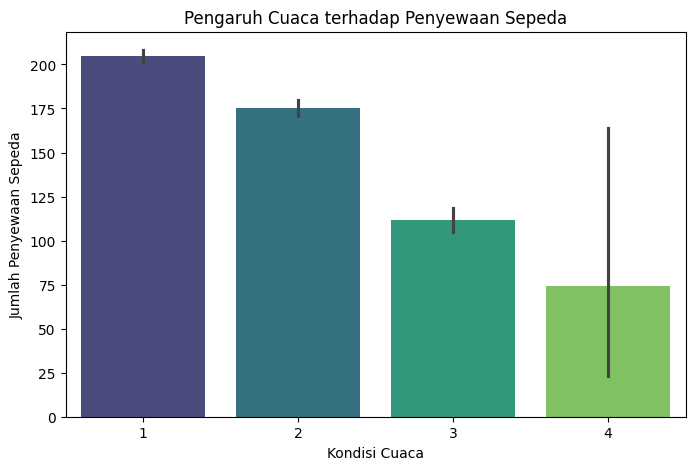

In [7]:
#Grafik 1 Cuaca
plt.figure(figsize=(8,5))

sns.barplot(
    x='weathersit',
    y='cnt',
    data=day_df,
    palette='viridis'
)

plt.title('Pengaruh Cuaca terhadap Penyewaan Sepeda')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Jumlah Penyewaan Sepeda')

plt.show()

### Pertanyaan 2:

/var/folders/3x/61_q0r7d3bz2ykcn36t0g7wm0000gn/T/ipykernel_1600/3004482566.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


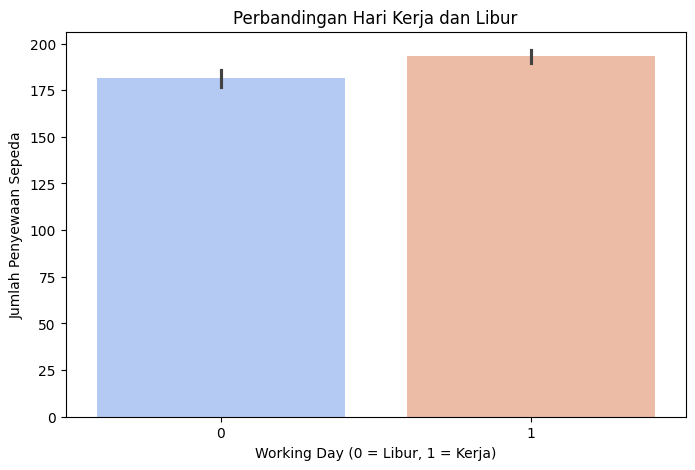

In [8]:
# Grafik 2
plt.figure(figsize=(8,5))

sns.barplot(
    x='workingday',
    y='cnt',
    data=day_df,
    palette='coolwarm'
)

plt.title('Perbandingan Hari Kerja dan Libur')
plt.xlabel('Working Day (0 = Libur, 1 = Kerja)')
plt.ylabel('Jumlah Penyewaan Sepeda')

plt.show()

**Insight:** (Opsional)

**Pertanyaan 1**
- Kondisi cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda.
- Cuaca yang lebih baik (clear) menghasilkan jumlah penyewaan yang lebih tinggi.
- Sebaliknya, cuaca buruk menyebabkan penurunan jumlah penyewaan sepeda.
- Hal ini menunjukkan bahwa pengguna cenderung menggunakan sepeda pada kondisi cuaca yang mendukung.

**Pertanyaan 2:**
- Jumlah penyewaan sepeda lebih tinggi pada hari kerja dibandingkan hari libur.
- Hal ini menunjukkan bahwa sepeda banyak digunakan untuk aktivitas rutin seperti bekerja atau sekolah.
- Pada hari libur, penggunaan sepeda cenderung menurun karena berkurangnya aktivitas harian.

## Analisis Lanjutan (Opsional)

In [9]:
day_df[['temp', 'cnt']].head()

,temp,cnt
0,0.24,16
1,0.22,40
2,0.22,32
3,0.24,13
4,0.24,1


## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kondisi cuaca (weathersit) memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda (cnt). Cuaca yang lebih baik cenderung menghasilkan jumlah penyewaan yang lebih tinggi, sedangkan cuaca buruk menyebabkan penurunan penyewaan.
- **Conclusion pertanyaan 2:** Terdapat perbedaan jumlah penyewaan sepeda antara hari kerja dan hari libur. Penyewaan sepeda lebih tinggi pada hari kerja, yang menunjukkan bahwa sepeda banyak digunakan untuk aktivitas rutin seperti bekerja atau sekolah.

**Rekomendasi Action Item:**
- Menambah ketersediaan sepeda dan memastikan operasional optimal pada hari kerja karena permintaan lebih tinggi.
- Memberikan promo atau diskon pada hari libur dan kondisi cuaca buruk untuk meningkatkan jumlah penyewaan.
- Mengoptimalkan distribusi sepeda berdasarkan kondisi cuaca dan pola penggunaan agar lebih efisien.

In [16]:
os.makedirs('dashboard', exist_ok=True)

day_df.to_csv('dashboard/main_data.csv', index=False)

In [17]:
pd.read_csv('dashboard/main_data.csv').head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1
